# Question 3

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from collections import defaultdict

### Redefining the notion of ‘degree’ and ‘clustering coefficient’ for a weighted network to account for the edge weights.

In a weighted graph degree is not just the sum of edges coming in and out of nodes but rather the total sum of weights of all the edges  coming in the node with the sum of weights of all the nodes coming out of the node. 

As per weighted clustering coefficient we are now averaging all the weights in the associated triangle and normalising them over the total possible triangles instead of it being a simple count of all all closed triangles in between those neighbours.

---

The degree for a directed weighted graph is defined as follows : total-degree = in-degree + out-degree (otherwise called in-strength and out-strength) <br>
<br>
Where the in-degree is defined as the sum of the weights of all the edges that are directed into the node and the out-degree is defined as the sum of the weights of all the edges that are directed out of the node <br>
<br>
For example, a node which has 2 edges directed into a node with edge weights 5 and -2 and 1 edge directed out of the node <br>
with edge weight 6 then the indegree will be 5 + (-2) = 3 and the outdegree will be 6 and consequently the total degree will be 3 + 6 = 9.


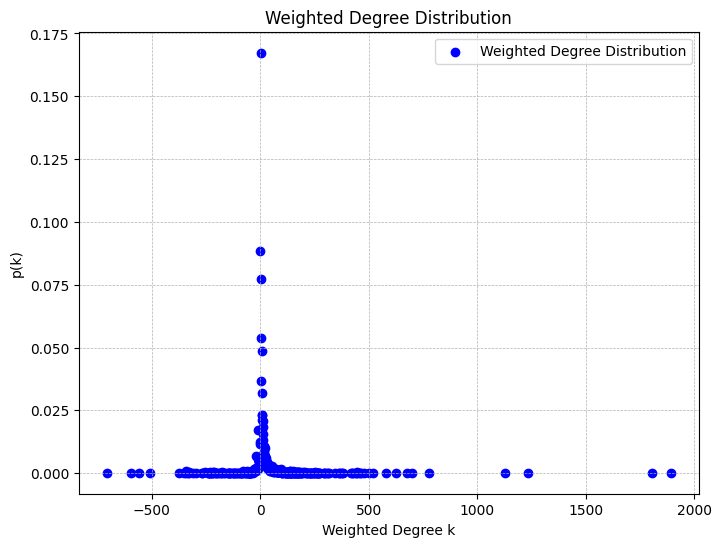

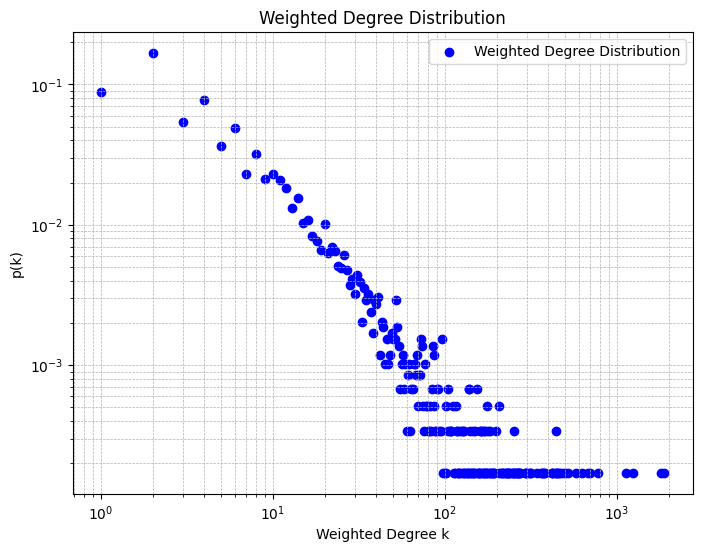

In [26]:
# Dictionaries to store in-strength and out-strength (sum of weights)
in_degree = {}
out_degree = {}

# Read the weighted directed edge list
with open("soc-sign-bitcoinotc.csv", "r") as file:
    for line in file:
        components = line.strip().split(",")
        src, dest, weight = map(int, components[:3])

        # Accumulate outgoing weight (out-strength)
        out_degree[src] = out_degree.get(src, 0) + weight

        # Accumulate incoming weight (in-strength)
        in_degree[dest] = in_degree.get(dest, 0) + weight


# Compute total strength (in + out) for each node
total_degree = {}
all_nodes = set(in_degree.keys()).union(set(out_degree.keys()))

for node in all_nodes:
    in_deg = in_degree.get(node, 0)
    out_deg = out_degree.get(node, 0)

    # Total weighted degree (strength)
    total_degree[node] = in_deg + out_deg


def plot_weighted_degree_distribution(total_degree, log_scale):
    # Count frequency of each strength value
    degree_counts = Counter(total_degree.values())

    # Extract k and corresponding probabilities
    k_vals = np.array(list(degree_counts.keys()))
    p_k = np.array(list(degree_counts.values())) / sum(degree_counts.values())

    plt.figure(figsize=(8, 6))
    plt.scatter(k_vals, p_k, marker='o', color='b',
                label="Weighted Degree Distribution")

    # Optional log-log scaling
    if log_scale:
        plt.xscale("log")
        plt.yscale("log")

    plt.xlabel("Weighted Degree k")
    plt.ylabel("p(k)")
    plt.title("Weighted Degree Distribution")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()


# Plot in linear scale
plot_weighted_degree_distribution(total_degree, 0)

# Plot in log-log scale
plot_weighted_degree_distribution(total_degree, 1)

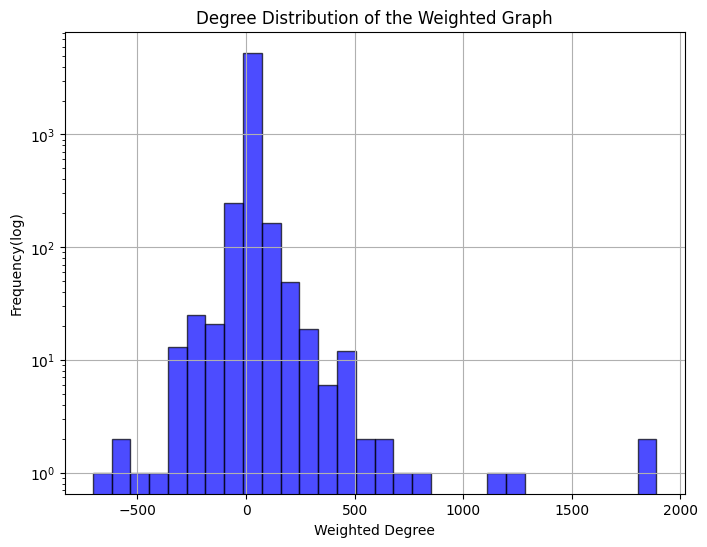

In [27]:
plt.figure(figsize=(8, 6))
plt.hist(total_degree.values(), bins=30, alpha=0.7, color='b', edgecolor='black')
plt.xlabel("Weighted Degree")
plt.yscale("log")
plt.ylabel("Frequency(log)")
plt.title("Degree Distribution of the Weighted Graph")
plt.grid(True)
plt.show()

The clustering coefficient for any node 'i' in a weighted directed graph is defined as follows : 

Weighted Clustering Coefficient (Directed Weighted Graph)

The clustering coefficient for a node i in a weighted directed graph is defined as:

        C_i = (2 / (k_i * (k_i - 1))) * Σ_{j,k} [ (w_ij + w_ik) / 2 ]

The summation runs over all pairs of neighboring nodes (j, k)
such that:
    - there exists an edge from i → j
    - there exists an edge from i → k
    - there exists an edge from j → k

Where:

        k_i   : total weighted degree (strength) of node i
        w_ij  : weight of the edge from node i to neighbor j
        w_ik  : weight of the edge from node i to neighbor k

This definition accounts for both connectivity and edge weights
when measuring local clustering around a node.

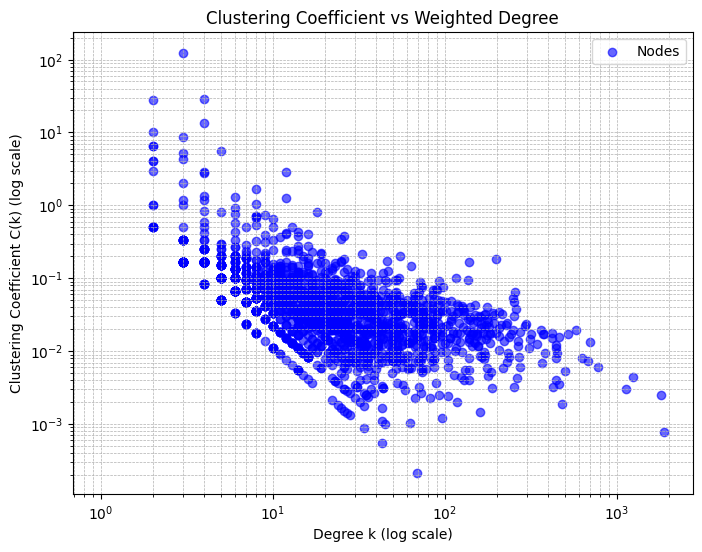

In [ ]:
# Store edge weights and neighbor relationships
weights = defaultdict(lambda: defaultdict(int))
neighbors = defaultdict(set)

# Read the weighted edge list
with open("soc-sign-bitcoinotc.csv", "r") as file:
    for line in file:
        components = line.strip().split(",")
        src, dest, weight = map(int, components[:3])

        # Save weight of edge src -> dest
        weights[src][dest] = weight

        # Track neighbors (treated as undirected for clustering)
        neighbors[src].add(dest)
        neighbors[dest].add(src)

clustering_coeffs = {}

# Compute weighted clustering coefficient for each node
for node in total_degree:

    # If degree is less than 2, clustering is zero
    if total_degree[node] < 2:
        clustering_coeffs[node] = 0.0
        continue

    sum_weights = 0
    neighbors_list = list(neighbors[node])

    # Check all pairs of neighbors
    for i in range(len(neighbors_list)):
        for j in range(i + 1, len(neighbors_list)):
            node_i, node_j = neighbors_list[i], neighbors_list[j]

            # Check if the two neighbors are connected
            if node_j in weights[node_i]:
                weight_ij = (weights[node].get(node_i, 0) +
                             weights[node].get(node_j, 0)) / 2
                sum_weights += weight_ij

    k_total = total_degree[node]

    # Apply clustering formula
    if k_total > 1:
        clustering_coeffs[node] = (2 * sum_weights) / (k_total * (k_total - 1))
    else:
        clustering_coeffs[node] = 0


# Prepare data for plotting
degrees = list(total_degree.values())
clustering_values = list(clustering_coeffs.values())

plt.figure(figsize=(8, 6))
plt.scatter(degrees, clustering_values, alpha=0.6, color="b", label="Nodes")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree k (log scale)")
plt.ylabel("Clustering Coefficient C(k) (log scale)")
plt.title("Clustering Coefficient vs Weighted Degree")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


### Interpretation: 

- The weighted degree (strength) distribution is heavy-tailed, indicating strong heterogeneity in user activity. A small number of users accumulate very high total interaction weights, while most users have low strength. This suggests the presence of influential or highly trusted users.

- The negative correlation between clustering coefficient and degree indicates hierarchical organization. Low-degree nodes tend to form tightly connected local groups, whereas high-degree nodes act as bridges between communities and exhibit lower clustering.

- The presence of negative weighted degrees reflects the signed nature of the trust network. Since edge weights represent positive and negative ratings, node strength captures both trust accumulation and distrust, making the structure more complex than unsigned social networks.

- Overall, the network exhibits structural heterogeneity, hierarchical organization, and signed interactions-key characteristics of real-world weighted social system
